In [5]:
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Callable, Dict
import yfinance as yf


# ======================================================
# Common model / utilities
# ======================================================

@dataclass
class MarketParams:
    r: float          # risk-free rate per step
    mu: float         # expected risky return per step
    sigma: float      # risky std dev per step
    dt: float         # time step length (years)
    T: float          # total horizon (years)
    n_steps: int      # number of time steps


@dataclass
class DPGrid:
    w_min: float      # minimum wealth in grid
    w_max: float      # maximum wealth in grid
    n_points: int     # number of grid points
    n_controls: int   # number of control discretization points

    def wealth_grid(self) -> np.ndarray:
        return np.linspace(self.w_min, self.w_max, self.n_points)

    def control_grid(self, pi_min: float, pi_max: float) -> np.ndarray:
        return np.linspace(pi_min, pi_max, self.n_controls)


def simulate_step(
    W: np.ndarray,
    pi: np.ndarray,
    params: MarketParams,
    rng: np.random.Generator
) -> np.ndarray:
    """
    One-step Euler update for wealth with fraction pi in risky asset.
    W_{t+1} = W_t * [ 1 + r + pi * (mu - r) + pi * sigma * eps ].
    """
    eps = rng.normal(size=W.shape)
    gross = 1.0 + params.r + pi * (params.mu - params.r) + pi * params.sigma * eps
    return W * gross


def interpolate_on_grid(
    w_grid: np.ndarray,
    V_grid: np.ndarray,
    w_vals: np.ndarray
) -> np.ndarray:
    """
    Simple linear interpolation of value function on wealth grid.
    """
    return np.interp(w_vals, w_grid, V_grid, left=V_grid[0], right=V_grid[-1])


# ======================================================
# Method A: Goal-hitting probability DP (Browne-style)
# ======================================================

def dp_goal_probability(
    params: MarketParams,
    grid: DPGrid,
    G: float,
    pi_min: float,
    pi_max: float,
    n_mc: int = 2000,
    seed: int = 0
) -> Dict[str, np.ndarray]:
    """
    Dynamic programming to maximize P(W_T >= G).

    Returns:
      V: value function array [n_steps+1, n_points]
      Pi: optimal control array [n_steps, n_points]
      w_grid: wealth grid
      pi_grid: control grid
    """
    rng = np.random.default_rng(seed)
    w_grid = grid.wealth_grid()
    pi_grid = grid.control_grid(pi_min, pi_max)

    n_steps = params.n_steps
    n_w = len(w_grid)

    V = np.zeros((n_steps + 1, n_w))
    Pi = np.zeros((n_steps, n_w))

    # terminal condition: indicator of reaching goal
    V[-1, :] = (w_grid >= G).astype(float)

    for n in reversed(range(n_steps)):
        V_next = V[n + 1, :]
        V_curr = np.zeros_like(V_next)
        Pi_curr = np.zeros_like(V_next)

        for i, w in enumerate(w_grid):
            best_val = -np.inf
            best_pi = 0.0

            for pi in pi_grid:
                W0 = np.full(n_mc, w)
                pi_vec = np.full(n_mc, pi)
                W_next = simulate_step(W0, pi_vec, params, rng)
                V_next_vals = interpolate_on_grid(w_grid, V_next, W_next)
                val = V_next_vals.mean()

                if val > best_val:
                    best_val = val
                    best_pi = pi

            V_curr[i] = best_val
            Pi_curr[i] = best_pi

        V[n, :] = V_curr
        Pi[n, :] = Pi_curr

    return {"V": V, "Pi": Pi, "w_grid": w_grid, "pi_grid": pi_grid}


# ======================================================
# Method B: Shortfall minimization DP
# ======================================================

def dp_shortfall_minimization(
    params: MarketParams,
    grid: DPGrid,
    G: float,
    loss_fn_terminal: Callable[[np.ndarray], np.ndarray],
    pi_min: float,
    pi_max: float,
    n_mc: int = 2000,
    seed: int = 0
) -> Dict[str, np.ndarray]:
    """
    Dynamic programming to minimize E[ loss((G - W_T)^+) ].

    Terminal cost: loss((G - W_T)^+)
    No running cost for simplicity.
    """
    rng = np.random.default_rng(seed)
    w_grid = grid.wealth_grid()
    pi_grid = grid.control_grid(pi_min, pi_max)

    n_steps = params.n_steps
    n_w = len(w_grid)

    J = np.zeros((n_steps + 1, n_w))
    Pi = np.zeros((n_steps, n_w))

    # terminal cost
    shortfall_T = np.maximum(G - w_grid, 0.0)
    J[-1, :] = loss_fn_terminal(shortfall_T)

    for n in reversed(range(n_steps)):
        J_next = J[n + 1, :]
        J_curr = np.zeros_like(J_next)
        Pi_curr = np.zeros_like(J_next)

        for i, w in enumerate(w_grid):
            best_val = np.inf
            best_pi = 0.0

            for pi in pi_grid:
                W0 = np.full(n_mc, w)
                pi_vec = np.full(n_mc, pi)
                W_next = simulate_step(W0, pi_vec, params, rng)
                J_next_vals = interpolate_on_grid(w_grid, J_next, W_next)
                val = J_next_vals.mean()

                if val < best_val:
                    best_val = val
                    best_pi = pi

            J_curr[i] = best_val
            Pi_curr[i] = best_pi

        J[n, :] = J_curr
        Pi[n, :] = Pi_curr

    return {"J": J, "Pi": Pi, "w_grid": w_grid, "pi_grid": pi_grid}


# ======================================================
# Method C: Entropic robust / risk-sensitive goal utility DP
# ======================================================

def goal_utility_smooth(
    w: np.ndarray,
    G: float,
    gamma: float = 0.8,
    bonus: float = 1.0,
    smooth_width: float = 0.05
) -> np.ndarray:
    """
    Example smooth goal-based utility:
      - Below goal: (w/G)^gamma
      - Around goal: smooth transition
      - Above goal: (w/G)^gamma + bonus (approx).
    For simplicity here: just (w/G)^gamma + bonus * sigmoid((w-G)/smooth_width).
    """
    w = np.maximum(w, 1e-12)
    base = (w / G) ** gamma
    z = (w - G) / (smooth_width * G)
    # smooth bonus via logistic sigmoid
    bonus_part = bonus / (1.0 + np.exp(-z))
    return base + bonus_part


def transformed_utility_entropic(
    w: np.ndarray,
    G: float,
    a: float,
    gamma: float = 0.8,
    bonus: float = 1.0,
    smooth_width: float = 0.05
) -> np.ndarray:
    """
    Entropic reduction: W(w) = -1/a * exp(-a * U(w)).
    """
    U = goal_utility_smooth(w, G, gamma=gamma, bonus=bonus, smooth_width=smooth_width)
    return - (1.0 / a) * np.exp(-a * U)


def dp_risk_sensitive_goal(
    params: MarketParams,
    grid: DPGrid,
    G: float,
    a: float,
    pi_min: float,
    pi_max: float,
    n_mc: int = 2000,
    seed: int = 0
) -> Dict[str, np.ndarray]:
    """
    Dynamic programming for entropic robust goal-based problem
    via risk-sensitive transformed utility W(w) = -1/a exp(-a U(w)).
    """
    rng = np.random.default_rng(seed)
    w_grid = grid.wealth_grid()
    pi_grid = grid.control_grid(pi_min, pi_max)

    n_steps = params.n_steps
    n_w = len(w_grid)

    V = np.zeros((n_steps + 1, n_w))
    Pi = np.zeros((n_steps, n_w))

    # terminal condition: transformed utility
    V[-1, :] = transformed_utility_entropic(w_grid, G, a=a)

    for n in reversed(range(n_steps)):
        V_next = V[n + 1, :]
        V_curr = np.zeros_like(V_next)
        Pi_curr = np.zeros_like(V_next)

        for i, w in enumerate(w_grid):
            best_val = -np.inf
            best_pi = 0.0

            for pi in pi_grid:
                W0 = np.full(n_mc, w)
                pi_vec = np.full(n_mc, pi)
                W_next = simulate_step(W0, pi_vec, params, rng)
                V_next_vals = interpolate_on_grid(w_grid, V_next, W_next)
                val = V_next_vals.mean()

                if val > best_val:
                    best_val = val
                    best_pi = pi

            V_curr[i] = best_val
            Pi_curr[i] = best_pi

        V[n, :] = V_curr
        Pi[n, :] = Pi_curr

    return {"V": V, "Pi": Pi, "w_grid": w_grid, "pi_grid": pi_grid}


# ======================================================
# Data: 10 largest tech/mega-cap style tickers (example)
# ======================================================

def download_equal_weight_index(
    tickers,
    start: str = "2010-01-01",
    end: str = None,
    freq: str = "M"
) -> pd.Series:
    """
    Download adjusted close prices for tickers, build equal-weighted index,
    and return a time series of gross returns at the given frequency.

    freq: "M" for month-end, "W" for weekly, etc.
    """
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    # data['Adj Close'] shape: (T, len(tickers))
    if 'Adj Close' in data:
        prices = data['Adj Close']
    else:
        # older yfinance or structure
        prices = data

    # resample to desired frequency (use last price of period)
    prices = prices.resample(freq).last().dropna()

    # equal-weight index
    eq_index = prices.mean(axis=1)

    # compute gross returns
    R = eq_index.pct_change().dropna()
    gross = 1.0 + R

    return gross


def estimate_market_params_from_returns(
    gross_returns: pd.Series,
    horizon_years: float,
    steps_per_year: int
) -> MarketParams:
    """
    Estimate a simple 1D GBM-type model from equal-weight index returns.
    Assume r ~ 0 for simplicity or estimate from Treasury elsewhere.
    """
    dt = 1.0 / steps_per_year
    # convert gross returns to simple returns per step frequency (same as gross_returns frequency)
    simple_returns = gross_returns - 1.0
    mu_hat = simple_returns.mean()
    sigma_hat = simple_returns.std(ddof=1)
    r_hat = 0.0  # set to 0 for simplicity; you can replace with T-bill yield

    n_steps = int(horizon_years * steps_per_year)

    return MarketParams(
        r=r_hat,
        mu=mu_hat,
        sigma=sigma_hat,
        dt=dt,
        T=horizon_years,
        n_steps=n_steps
    )


# ======================================================
# Backtest / evaluation helpers
# ======================================================

def simulate_strategy_paths(
    params: MarketParams,
    Pi: np.ndarray,
    w_grid: np.ndarray,
    W0: float,
    n_paths: int = 10000,
    seed: int = 123
) -> np.ndarray:
    """
    Simulate wealth paths under a feedback strategy Pi[t_idx, w_idx].
    For each time t and wealth w, we use nearest-neighbour on w_grid to pick pi.
    """
    rng = np.random.default_rng(seed)
    n_steps = params.n_steps
    W = np.full((n_paths,), W0)

    for n in range(n_steps):
        # pick control based on current wealth
        idx = np.clip(np.searchsorted(w_grid, W) - 1, 0, len(w_grid) - 1)
        pi = Pi[n, idx]
        W = simulate_step(W, pi, params, rng)

    return W


# ======================================================
# Main example tying everything together
# ======================================================

def main():
    # 10 large US names (approx large-cap set; you can change this list)
    tickers = [
        "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA",
        "META", "TSLA", "BRK-B", "LLY", "AVGO"
    ]

    print("Downloading data...")
    gross_full = download_equal_weight_index(tickers, start="2010-01-01", freq="M")
    print(f"Got {len(gross_full)} monthly observations.")

    # Split data into in-sample and out-of-sample
    split_idx = int(len(gross_full) * 0.8)
    gross_in_sample = gross_full.iloc[:split_idx]
    gross_out_of_sample = gross_full.iloc[split_idx:]

    print(f"In-sample data from {gross_in_sample.index.min().strftime('%Y-%m-%d')} to {gross_in_sample.index.max().strftime('%Y-%m-%d')} ({len(gross_in_sample)} months)")
    print(f"Out-of-sample data from {gross_out_of_sample.index.min().strftime('%Y-%m-%d')} to {gross_out_of_sample.index.max().strftime('%Y-%m-%d')} ({len(gross_out_of_sample)} months)")

    # Choose horizon and steps per year consistent with data frequency
    horizon_years = 5.0
    steps_per_year = 12  # monthly DP

    # --- In-sample parameters and DP calculation ---
    print("\nEstimating IN-SAMPLE market parameters...")
    params_in_sample = estimate_market_params_from_returns(
        gross_returns=gross_in_sample,
        horizon_years=horizon_years,
        steps_per_year=steps_per_year
    )

    print("In-sample market parameters:")
    print(f"  r     (per step) ~ {params_in_sample.r:.4f}")
    print(f"  mu    (per step) ~ {params_in_sample.mu:.4f}")
    print(f"  sigma (per step) ~ {params_in_sample.sigma:.4f}")

    # DP grid and controls (common for all methods)
    W0 = 1.0
    G = 1.5  # target wealth 1.5x initial
    grid = DPGrid(
        w_min=0.0,
        w_max=3.0,
        n_points=81,
        n_controls=21
    )
    pi_min, pi_max = -0.5, 2.0  # allow some shorting and leverage

    # -----------------------------------------------------
    # Method A: goal probability (using in-sample parameters)
    # -----------------------------------------------------
    print("\nRunning Method A: Goal-hitting probability DP (in-sample)...")
    res_A = dp_goal_probability(
        params=params_in_sample,
        grid=grid,
        G=G,
        pi_min=pi_min,
        pi_max=pi_max,
        n_mc=2000,
        seed=1
    )

    # ----------------------------------------------------------------
    # Method B: shortfall minimization (quadratic loss) (in-sample parameters)
    # ----------------------------------------------------------------
    print("Running Method B: Shortfall minimization DP (in-sample)...")
    def loss_terminal(shortfall: np.ndarray) -> np.ndarray:
        return shortfall ** 2  # quadratic loss

    res_B = dp_shortfall_minimization(
        params=params_in_sample,
        grid=grid,
        G=G,
        loss_fn_terminal=loss_terminal,
        pi_min=pi_min,
        pi_max=pi_max,
        n_mc=2000,
        seed=2
    )

    # --------------------------------------------------------------
    # Method C: entropic robust (risk-sensitive) (in-sample parameters)
    # --------------------------------------------------------------
    print("Running Method C: Entropic robust DP (in-sample)...")
    a = 2.0  # ambiguity / risk-sensitivity parameter
    res_C = dp_risk_sensitive_goal(
        params=params_in_sample,
        grid=grid,
        G=G,
        a=a,
        pi_min=pi_min,
        pi_max=pi_max,
        n_mc=2000,
        seed=3
    )

    # --- Out-of-sample parameters for backtesting simulations ---
    print("\nEstimating OUT-OF-SAMPLE market parameters...")
    params_out_of_sample = estimate_market_params_from_returns(
        gross_returns=gross_out_of_sample,
        horizon_years=horizon_years,
        steps_per_year=steps_per_year
    )

    print("Out-of-sample market parameters:")
    print(f"  r     (per step) ~ {params_out_of_sample.r:.4f}")
    print(f"  mu    (per step) ~ {params_out_of_sample.mu:.4f}")
    print(f"  sigma (per step) ~ {params_out_of_sample.sigma:.4f}")

    # =========================
    # In-sample simulation comparison
    # =========================
    print("\nSimulating strategies (IN-SAMPLE market conditions)...")

    w_grid = res_A["w_grid"]

    # Simulate each strategy's terminal wealth distribution using IN-SAMPLE params
    W_final_A_in_sample = simulate_strategy_paths(
        params=params_in_sample,
        Pi=res_A["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=10
    )

    W_final_B_in_sample = simulate_strategy_paths(
        params=params_in_sample,
        Pi=res_B["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=11
    )

    W_final_C_in_sample = simulate_strategy_paths(
        params=params_in_sample,
        Pi=res_C["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=12
    )

    def summarize(name: str, W_final: np.ndarray, G: float):
        prob_goal = np.mean(W_final >= G)
        mean_W = np.mean(W_final)
        # Calculate ES_5% shortfall only if there are shortfalls to avoid division by zero or empty array issues
        shortfalls = (G - W_final[W_final < G]).clip(min=0.0)
        es_5 = np.mean(shortfalls[shortfalls > 0]) if len(shortfalls[shortfalls > 0]) > 0 else 0.0

        print(f"{name}:")
        print(f"  E[W_T]          = {mean_W:.3f}")
        print(f"  P(W_T >= G)     = {prob_goal:.3f}")
        print(f"  ES_5% shortfall = {es_5:.3f}")

    print("\n--- IN-SAMPLE Performance Summary ---")
    summarize("Method A (Goal probability)", W_final_A_in_sample, G)
    summarize("Method B (Shortfall min)", W_final_B_in_sample, G)
    summarize("Method C (Entropic robust)", W_final_C_in_sample, G)

    # =========================
    # Out-of-sample simulation comparison (Backtest)
    # =========================
    print("\nSimulating strategies (OUT-OF-SAMPLE market conditions - Backtest)...")

    # Simulate each strategy's terminal wealth distribution using OUT-OF-SAMPLE params
    W_final_A_out_of_sample = simulate_strategy_paths(
        params=params_out_of_sample,
        Pi=res_A["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=20 # Use a different seed for out-of-sample simulations
    )

    W_final_B_out_of_sample = simulate_strategy_paths(
        params=params_out_of_sample,
        Pi=res_B["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=21
    )

    W_final_C_out_of_sample = simulate_strategy_paths(
        params=params_out_of_sample,
        Pi=res_C["Pi"],
        w_grid=w_grid,
        W0=W0,
        n_paths=5000,
        seed=22
    )

    print("\n--- OUT-OF-SAMPLE Performance Summary ---")
    summarize("Method A (Goal probability)", W_final_A_out_of_sample, G)
    summarize("Method B (Shortfall min)", W_final_B_out_of_sample, G)
    summarize("Method C (Entropic robust)", W_final_C_out_of_sample, G)

    # Return all necessary results for plotting (using in-sample for consistent plots)
    return res_A, res_B, res_C, W0, G, pi_min, pi_max, \
           W_final_A_in_sample, W_final_B_in_sample, W_final_C_in_sample, \
           W_final_A_out_of_sample, W_final_B_out_of_sample, W_final_C_out_of_sample

if __name__ == "__main__":
    # This block will not be executed when main() is called from another cell
    # The global assignment will be handled by the added cell.
    pass

### Visualizing Results

Let's visualize the results from the three dynamic programming methods: Goal-hitting probability, Shortfall minimization, and Entropic robust. We'll plot the initial value/cost functions, the initial optimal policies, and the terminal wealth distributions from the simulations.

In [8]:
# Call main function and store results in global variables for plotting.
res_A, res_B, res_C, W0, G, pi_min, pi_max, W_final_A, W_final_B, W_final_C, W_final_A_out_of_sample, W_final_B_out_of_sample, W_final_C_out_of_sample = main()

/tmp/ipykernel_5278/1483575712.py:311: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prices = prices.resample(freq).last().dropna()


Got 167 monthly observations.
In-sample data from 2012-06-30 to 2023-06-30 (133 months)
Out-of-sample data from 2023-07-31 to 2026-04-30 (34 months)

Estimating IN-SAMPLE market parameters...
In-sample market parameters:
  r     (per step) ~ 0.0000
  mu    (per step) ~ 0.0695
  sigma (per step) ~ 0.4329

Running Method A: Goal-hitting probability DP (in-sample)...
Running Method B: Shortfall minimization DP (in-sample)...
Running Method C: Entropic robust DP (in-sample)...

Estimating OUT-OF-SAMPLE market parameters...
Out-of-sample market parameters:
  r     (per step) ~ 0.0000
  mu    (per step) ~ 0.0419
  sigma (per step) ~ 0.3736

Simulating strategies (IN-SAMPLE market conditions)...

--- IN-SAMPLE Performance Summary ---
Method A (Goal probability):
  E[W_T]          = 1.449
  P(W_T >= G)     = 0.927
  ES_5% shortfall = 1.483
Method B (Shortfall min):
  E[W_T]          = 1.371
  P(W_T >= G)     = 0.142
  ES_5% shortfall = 0.156
Method C (Entropic robust):
  E[W_T]          = 1.58

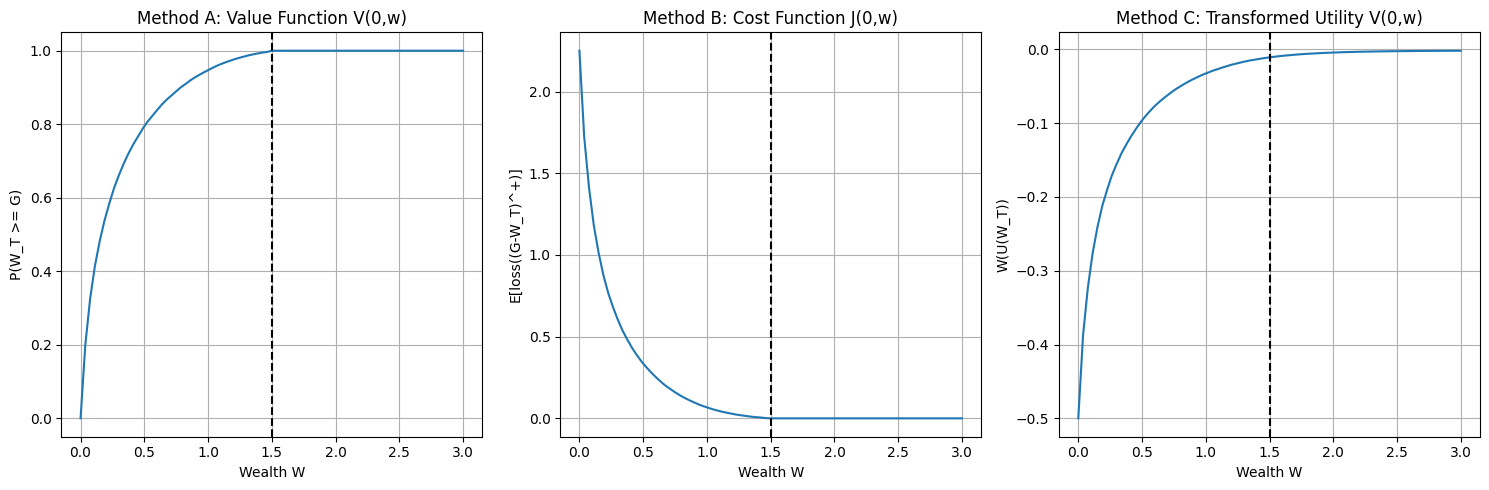

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plotting Value/Cost Functions at t=0 ---
w_grid = res_A['w_grid'] # Wealth grid is common

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(w_grid, res_A['V'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method A: Value Function V(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('P(W_T >= G)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(w_grid, res_B['J'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method B: Cost Function J(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('E[loss((G-W_T)^+)]')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(w_grid, res_C['V'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method C: Transformed Utility V(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('W(U(W_T))')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Plotting Optimal Policies at t=0 ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(w_grid, res_A['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method A: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(w_grid, res_B['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method B: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(w_grid, res_C['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method C: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.tight_layout()
plt.show()

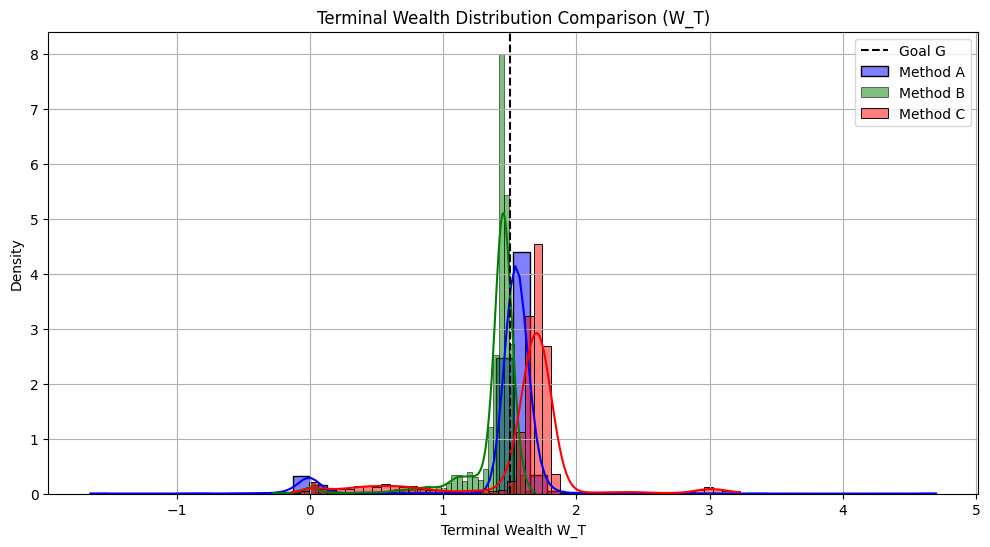

In [12]:
# --- Plotting Terminal Wealth Distributions ---
plt.figure(figsize=(12, 6))
sns.histplot(W_final_A, bins=50, color='blue', label='Method A', kde=True, stat='density', alpha=0.5)
sns.histplot(W_final_B, bins=50, color='green', label='Method B', kde=True, stat='density', alpha=0.5)
sns.histplot(W_final_C, bins=50, color='red', label='Method C', kde=True, stat='density', alpha=0.5)

plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Terminal Wealth Distribution Comparison (W_T)')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

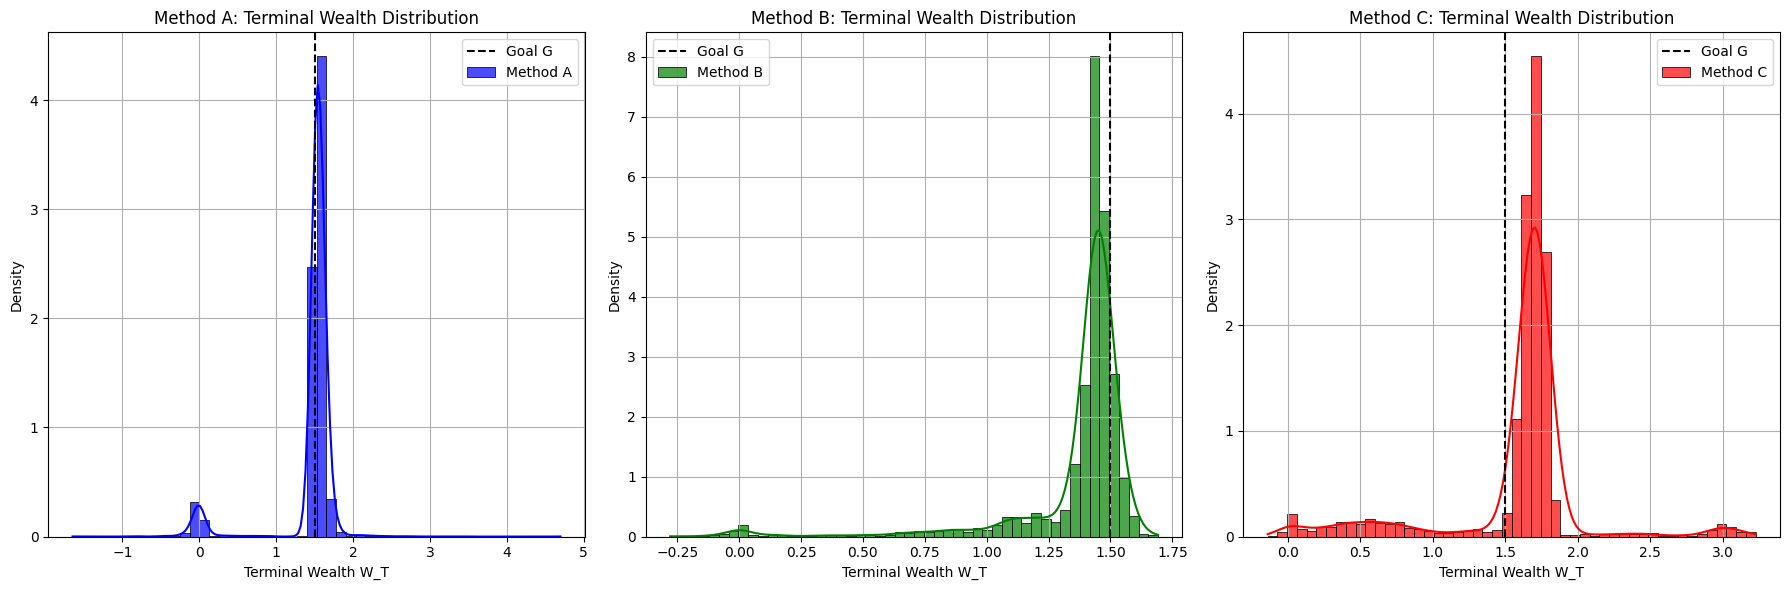

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6)) # Increased figure size for three subplots

# Method A Distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
sns.histplot(W_final_A, bins=50, color='blue', label='Method A', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method A: Terminal Wealth Distribution')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Method B Distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
sns.histplot(W_final_B, bins=50, color='green', label='Method B', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method B: Terminal Wealth Distribution')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Method C Distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
sns.histplot(W_final_C, bins=50, color='red', label='Method C', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method C: Terminal Wealth Distribution')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# --- Plotting Optimal Policies at t=0 ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(w_grid, res_A['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method A: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(w_grid, res_B['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method B: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(w_grid, res_C['Pi'][0, :])
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method C: Optimal Policy Pi(0,w)')
plt.xlabel('Wealth W')
plt.ylabel('Optimal Risky Allocation (pi)')
plt.ylim(pi_min, pi_max)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def summarize(name: str, W_final: np.ndarray, G: float):
    prob_goal = np.mean(W_final >= G)
    mean_W = np.mean(W_final)
    # Calculate ES_5% shortfall only if there are shortfalls to avoid division by zero or empty array issues
    shortfalls = (G - W_final[W_final < G]).clip(min=0.0)
    es_5 = np.mean(shortfalls[shortfalls > 0]) if len(shortfalls[shortfalls > 0]) > 0 else 0.0

    print(f"{name}:")
    print(f"  E[W_T]          = {mean_W:.3f}")
    print(f"  P(W_T >= G)     = {prob_goal:.3f}")
    print(f"  ES_5% shortfall = {es_5:.3f}")

print("\n--- OUT-OF-SAMPLE Performance Summary ---")
summarize("Method A (Goal probability)", W_final_A_out_of_sample, G)
summarize("Method B (Shortfall min)", W_final_B_out_of_sample, G)
summarize("Method C (Entropic robust)", W_final_C_out_of_sample, G)

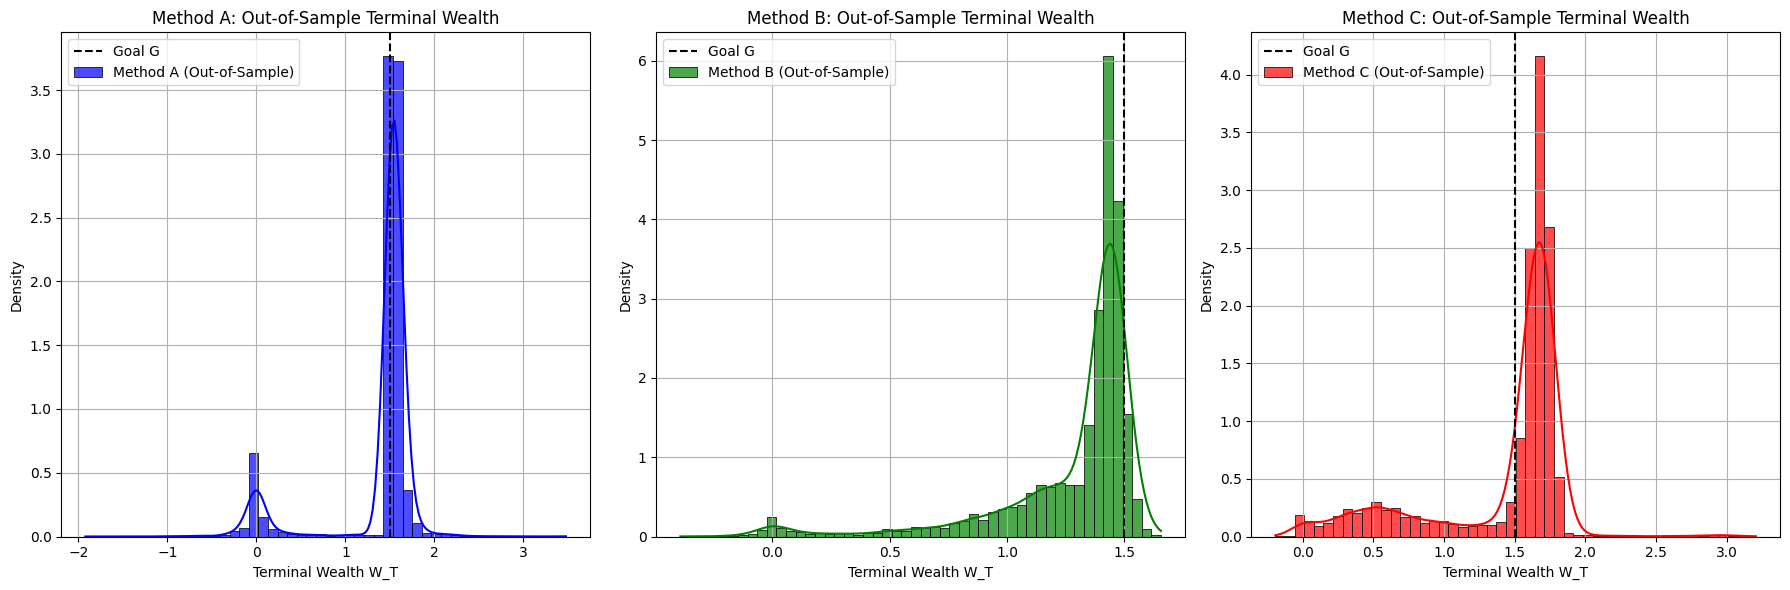

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 6)) # Increased figure size for three subplots

# Method A Out-of-Sample Distribution
plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st subplot
sns.histplot(W_final_A_out_of_sample, bins=50, color='blue', label='Method A (Out-of-Sample)', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method A: Out-of-Sample Terminal Wealth')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Method B Out-of-Sample Distribution
plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd subplot
sns.histplot(W_final_B_out_of_sample, bins=50, color='green', label='Method B (Out-of-Sample)', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method B: Out-of-Sample Terminal Wealth')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Method C Out-of-Sample Distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd subplot
sns.histplot(W_final_C_out_of_sample, bins=50, color='red', label='Method C (Out-of-Sample)', kde=True, stat='density', alpha=0.7)
plt.axvline(G, color='k', linestyle='--', label='Goal G')
plt.title('Method C: Out-of-Sample Terminal Wealth')
plt.xlabel('Terminal Wealth W_T')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5278/1483575712.py:311: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prices = prices.resample(freq).last().dropna()


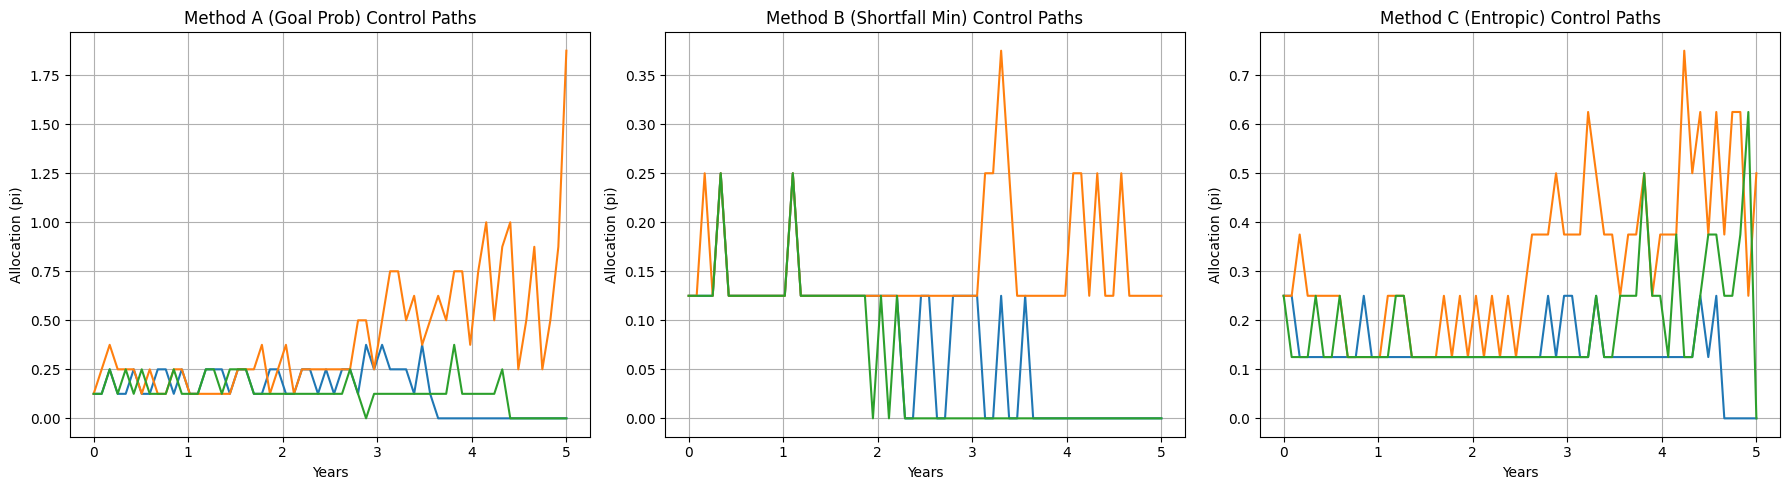

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def get_control_paths(params, Pi, w_grid, W0, n_paths=3, seed=42):
    rng = np.random.default_rng(seed)
    n_steps = params.n_steps
    W = np.full((n_paths,), W0)
    pi_paths = np.zeros((n_steps, n_paths))

    for n in range(n_steps):
        # Find closest wealth index for each path to pick the pre-computed optimal pi
        idx = np.clip(np.searchsorted(w_grid, W) - 1, 0, len(w_grid) - 1)
        pi_current = Pi[n, idx]
        pi_paths[n, : ] = pi_current
        W = simulate_step(W, pi_current, params, rng)

    return pi_paths

# Ensure data is available
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "BRK-B", "LLY", "AVGO"]
gross_full = download_equal_weight_index(tickers, start="2010-01-01", freq="M")
split_idx = int(len(gross_full) * 0.8)
gross_out_of_sample = gross_full.iloc[split_idx:]

# Ensure results are available
try:
    _ = res_A
except NameError:
    res_A, res_B, res_C, W0, G, pi_min, pi_max, _, _, _, _, _, _ = main()

# Generate sample control paths using Out-of-Sample parameters
params_oos = estimate_market_params_from_returns(gross_out_of_sample, horizon_years=5.0, steps_per_year=12)
time_axis = np.linspace(0, 5.0, params_oos.n_steps)

pi_paths_A = get_control_paths(params_oos, res_A['Pi'], res_A['w_grid'], W0=1.0)
pi_paths_B = get_control_paths(params_oos, res_B['Pi'], res_B['w_grid'], W0=1.0)
pi_paths_C = get_control_paths(params_oos, res_C['Pi'], res_C['w_grid'], W0=1.0)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(time_axis, pi_paths_A)
plt.title('Method A (Goal Prob) Control Paths')
plt.xlabel('Years')
plt.ylabel('Allocation (pi)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(time_axis, pi_paths_B)
plt.title('Method B (Shortfall Min) Control Paths')
plt.xlabel('Years')
plt.ylabel('Allocation (pi)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(time_axis, pi_paths_C)
plt.title('Method C (Entropic) Control Paths')
plt.xlabel('Years')
plt.ylabel('Allocation (pi)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Re-running DP with high-resolution parameters
import numpy as np

# Ensure data and parameters are available
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'LLY', 'AVGO']
gross_full = download_equal_weight_index(tickers, start='2010-01-01', freq='M')
split_idx = int(len(gross_full) * 0.8)
gross_in_sample = gross_full.iloc[:split_idx]

params_in_sample = estimate_market_params_from_returns(
    gross_returns=gross_in_sample,
    horizon_years=5.0,
    steps_per_year=12
)

# Define the refined grid
refined_grid = DPGrid(
    w_min=0.0,
    w_max=3.0,
    n_points=201,
    n_controls=101
)

high_res_mc = 5000

print("Starting high-resolution DP calculations...")

# Method A: Goal Probability
res_A_fine = dp_goal_probability(
    params=params_in_sample,
    grid=refined_grid,
    G=G,
    pi_min=pi_min,
    pi_max=pi_max,
    n_mc=high_res_mc,
    seed=42
)
print("Method A complete.")

# Method B: Shortfall Minimization
res_B_fine = dp_shortfall_minimization(
    params=params_in_sample,
    grid=refined_grid,
    G=G,
    loss_fn_terminal=lambda s: s**2,
    pi_min=pi_min,
    pi_max=pi_max,
    n_mc=high_res_mc,
    seed=43
)
print("Method B complete.")

# Method C: Entropic Robust
res_C_fine = dp_risk_sensitive_goal(
    params=params_in_sample,
    grid=refined_grid,
    G=G,
    a=2.0,
    pi_min=pi_min,
    pi_max=pi_max,
    n_mc=high_res_mc,
    seed=44
)
print("Method C complete.")

print("High-resolution DP run finished successfully.")

/tmp/ipykernel_5278/1483575712.py:311: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  prices = prices.resample(freq).last().dropna()


Starting high-resolution DP calculations...


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def sensitivity_analysis():
    # Parameters to vary
    goals = [1.2, 1.5, 1.8]
    horizons = [1.0, 3.0, 5.0]
    alphas = [0.1, 2.0, 10.0]

    # Grid settings (using lower resolution for speed in sensitivity analysis)
    sens_grid = DPGrid(w_min=0.0, w_max=3.0, n_points=51, n_controls=21)
    n_mc_sens = 1000
    W0 = 1.0

    # Storage for results (Probability of hitting goal)
    results = np.zeros((len(horizons), len(goals)))

    # We'll fix alpha=2.0 for the G vs T heatmap, then vary alpha for a specific G,T
    fixed_alpha = 2.0

    print("Starting sensitivity analysis for Method C...")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Prob(W_T >= G) vs G and T
    for i, T in enumerate(horizons):
        for j, g_level in enumerate(goals):
            # Update params for specific T
            p = MarketParams(r=params_in_sample.r, mu=params_in_sample.mu,
                             sigma=params_in_sample.sigma, dt=1/12, T=T, n_steps=int(T*12))

            res = dp_risk_sensitive_goal(p, sens_grid, g_level, a=fixed_alpha,
                                         pi_min=pi_min, pi_max=pi_max, n_mc=n_mc_sens)

            W_final = simulate_strategy_paths(p, res['Pi'], res['w_grid'], W0=W0, n_paths=2000)
            results[i, j] = np.mean(W_final >= g_level)

    sns.heatmap(results, annot=True, xticklabels=goals, yticklabels=horizons, ax=axes[0], cmap="RdYlGn")
    axes[0].set_title(f'P(W_T >= G) vs Goal & Horizon (a={fixed_alpha})')
    axes[0].set_xlabel('Goal Level (G)')
    axes[0].set_ylabel('Horizon (T years)')

    # Plot 2: Prob(W_T >= G) vs a (Ambiguity) for a fixed G and T
    fixed_G = 1.5
    fixed_T = 3.0
    prob_vs_a = []
    for a_val in alphas:
        p = MarketParams(r=params_in_sample.r, mu=params_in_sample.mu,
                         sigma=params_in_sample.sigma, dt=1/12, T=fixed_T, n_steps=int(fixed_T*12))
        res = dp_risk_sensitive_goal(p, sens_grid, fixed_G, a=a_val,
                                     pi_min=pi_min, pi_max=pi_max, n_mc=n_mc_sens)
        W_final = simulate_strategy_paths(p, res['Pi'], res['w_grid'], W0=W0, n_paths=2000)
        prob_vs_a.append(np.mean(W_final >= fixed_G))

    axes[1].plot(alphas, prob_vs_a, marker='o', linewidth=2, color='red')
    axes[1].set_title(f'Impact of Ambiguity (a) on Success\n(G={fixed_G}, T={fixed_T})')
    axes[1].set_xlabel('Ambiguity Parameter (a)')
    axes[1].set_ylabel('P(W_T >= G)')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

sensitivity_analysis()